In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# FIX: n_redundant=0 add kiya gaya hai
X, y = make_classification(
    n_samples=100,
    n_features=4,
    n_informative=3,
    n_redundant=0,  # Ab error nahi aayega kyunki 3 + 0 < 4
    n_classes=2,
    random_state=42,
)

# Baki ka code bilkul same rahega
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Predictions on Test Data:", predictions)

accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Predictions on Test Data: [0 1 1 0 1 1 1 1 0 0 0 1 1 1 0 1 0 0 0 1]
Model Accuracy: 90.00%


--- Accuracy Comparison ---
Gini Tree Accuracy:    93.33%
Entropy Tree Accuracy: 93.33%



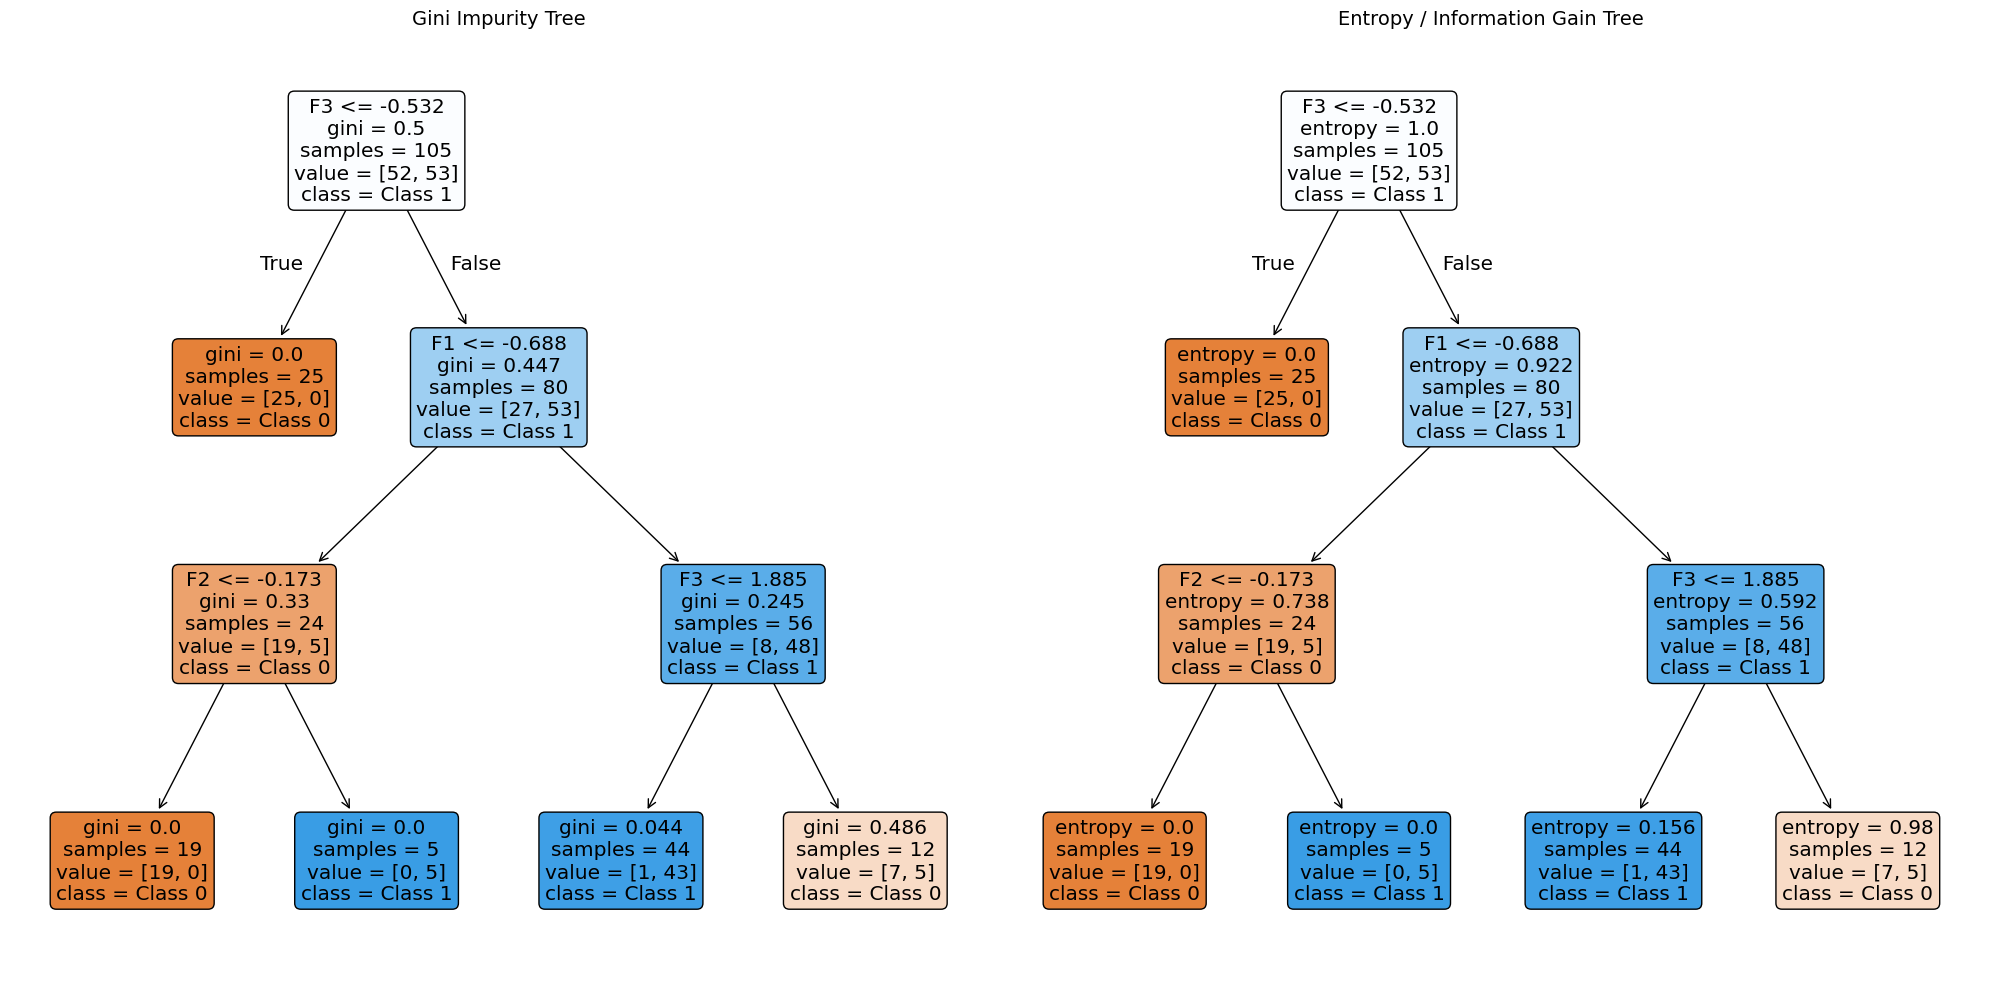

In [3]:
# Topic 104 | Decision Trees - Data Splitting & Feature Selection - Part I
# Topic 105 | Decision Trees - Data Splitting & Feature Selection - Part II

import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Dataset generate karein
X, y = make_classification(
    n_samples=150,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_classes=2,
    random_state=42,
)

# 2. Data ko Train aur Test sets mein split karein
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --------------------------------------------------
# MODEL 1: Gini Impurity (Part II ka concept)
# --------------------------------------------------
gini_tree = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
gini_tree.fit(X_train, y_train)
gini_accuracy = gini_tree.score(X_test, y_test)

# --------------------------------------------------
# MODEL 2: Entropy / Information Gain (Part I ka concept)
# --------------------------------------------------
entropy_tree = DecisionTreeClassifier(
    criterion="entropy", max_depth=3, random_state=42
)
entropy_tree.fit(X_train, y_train)
entropy_accuracy = entropy_tree.score(X_test, y_test)

# 3. Dono ki Accuracy Print Karein
print("--- Accuracy Comparison ---")
print(f"Gini Tree Accuracy:    {gini_accuracy * 100:.2f}%")
print(f"Entropy Tree Accuracy: {entropy_accuracy * 100:.2f}%\n")

# 4. Dono Trees ko side-by-side plot karein taake splits ka farq nazar aaye
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

# Gini Tree Plot
plot_tree(
    gini_tree,
    filled=True,
    feature_names=["F1", "F2", "F3", "F4"],
    class_names=["Class 0", "Class 1"],
    rounded=True,
    ax=axes[0],
)
axes[0].set_title("Gini Impurity Tree", fontsize=14)

# Entropy Tree Plot
plot_tree(
    entropy_tree,
    filled=True,
    feature_names=["F1", "F2", "F3", "F4"],
    class_names=["Class 0", "Class 1"],
    rounded=True,
    ax=axes[1],
)
axes[1].set_title("Entropy / Information Gain Tree", fontsize=14)

plt.tight_layout()
plt.show()

--- MODEL 1: Overfitted Tree (Unlimited Depth) ---
Training Accuracy: 100.00%
Testing Accuracy:  85.56%
Actual Tree Depth: 11

--- MODEL 2: Controlled Tree (max_depth=4) ---
Training Accuracy: 91.43%
Testing Accuracy:  86.67%
Actual Tree Depth: 4



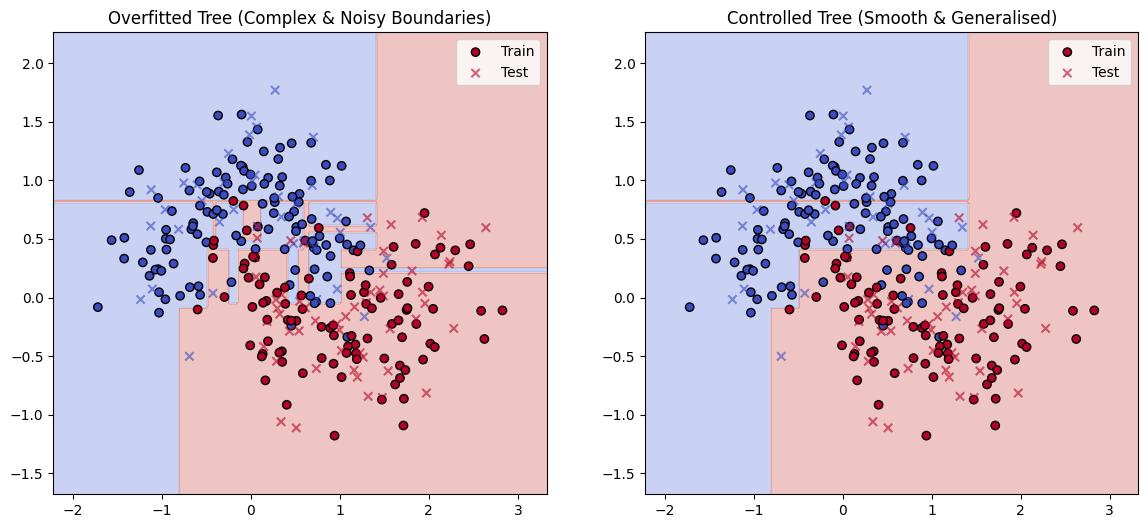

In [4]:
# Topic 106 | Decision Trees - Tree Depth & Overfitting
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Ek complex non-linear dataset generate karein (Moons Dataset)
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

# Data ko Train aur Test sets mein split karein
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ------------------------------------------------------------------
# MODEL 1: Overfitted Tree (No depth limit - default)
# ------------------------------------------------------------------
overfitted_model = DecisionTreeClassifier(random_state=42)  # max_depth=None
overfitted_model.fit(X_train, y_train)

train_acc_overfit = overfitted_model.score(X_train, y_train)
test_acc_overfit = overfitted_model.score(X_test, y_test)

# ------------------------------------------------------------------
# MODEL 2: Controlled/Regularized Tree (With max_depth)
# ------------------------------------------------------------------
controlled_model = DecisionTreeClassifier(max_depth=4, random_state=42)
controlled_model.fit(X_train, y_train)

train_acc_control = controlled_model.score(X_train, y_train)
test_acc_control = controlled_model.score(X_test, y_test)

# 2. Results Print Karein
print("--- MODEL 1: Overfitted Tree (Unlimited Depth) ---")
print(f"Training Accuracy: {train_acc_overfit * 100:.2f}%")
print(f"Testing Accuracy:  {test_acc_overfit * 100:.2f}%")
print(f"Actual Tree Depth: {overfitted_model.get_depth()}\n")

print("--- MODEL 2: Controlled Tree (max_depth=4) ---")
print(f"Training Accuracy: {train_acc_control * 100:.2f}%")
print(f"Testing Accuracy:  {test_acc_control * 100:.2f}%")
print(f"Actual Tree Depth: {controlled_model.get_depth()}\n")


# 3. Decision Boundaries Plot Karne Ka Function (Visual Proof)
def plot_boundaries(model, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(
        X_train[:, 0],
        X_train[:, 1],
        c=y_train,
        cmap="coolwarm",
        edgecolors="k",
        label="Train",
    )
    ax.scatter(
        X_test[:, 0],
        X_test[:, 1],
        c=y_test,
        cmap="coolwarm",
        marker="x",
        alpha=0.6,
        label="Test",
    )
    ax.set_title(title)
    ax.legend()


# Plots Display Karein
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_boundaries(
    overfitted_model, axes[0], "Overfitted Tree (Complex & Noisy Boundaries)"
)
plot_boundaries(
    controlled_model, axes[1], "Controlled Tree (Smooth & Generalised)"
)
plt.show()

Total unique alpha values found: 14
Best Alpha Value for Pruning: 0.0214

--- Accuracy Comparison ---
Unpruned Tree (Alpha=0) Test Accuracy: 100.00%
Pruned Tree (Best Alpha) Test Accuracy:  90.00%
Pruned Tree Depth: 5


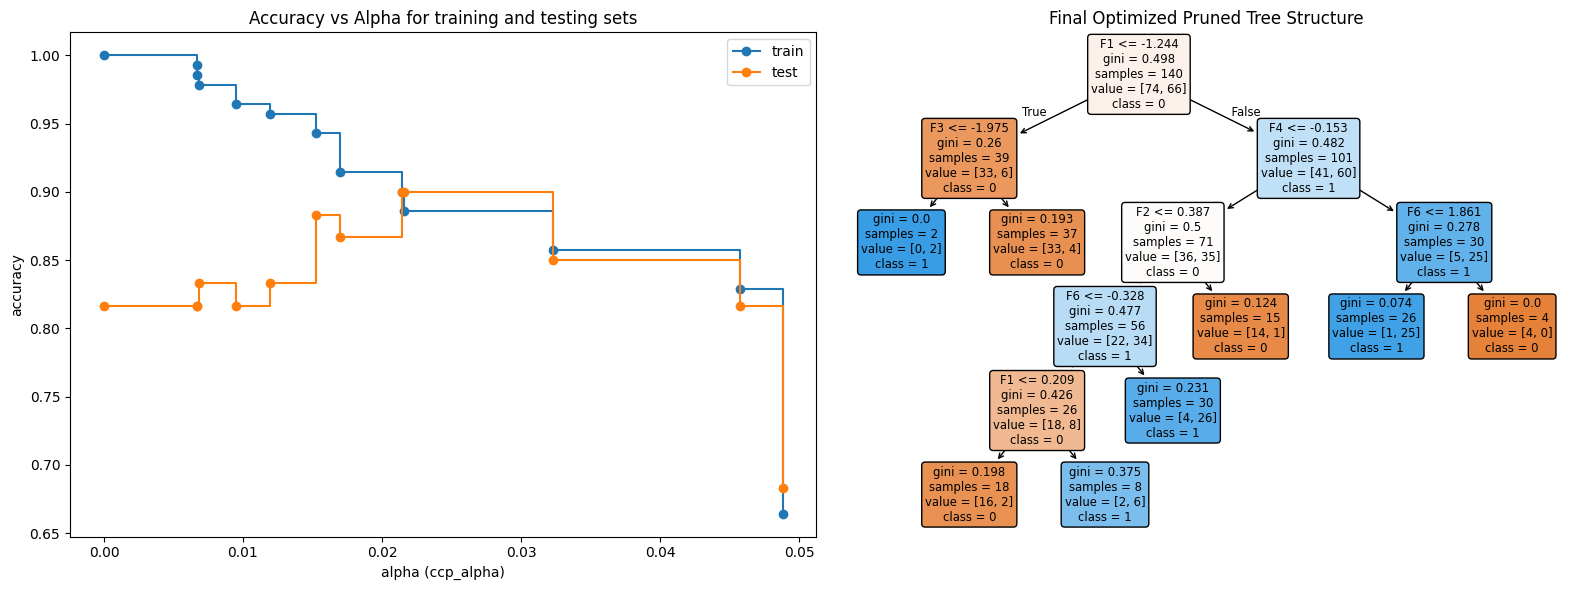

In [5]:
#Topic 107 | Decision Trees - Pruning Techniques
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Ek bada aur noisy dataset generate karein
X, y = make_classification(
    n_samples=200,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    random_state=42,
)

# Data split karein
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ------------------------------------------------------------------
# STEP 1: Poora tree grow karein aur effective alphas nikalyein
# ------------------------------------------------------------------
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

print(f"Total unique alpha values found: {len(ccp_alphas)}")

# ------------------------------------------------------------------
# STEP 2: Har alpha par ek tree train karein aur accuracy check karein
# ------------------------------------------------------------------
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs = clfs + [clf]

# Training aur Testing scores nikalyein (akhri alpha ko chorr kar kyunki woh pure tree ko khatam kar deta hai)
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

# ------------------------------------------------------------------
# STEP 3: Best Alpha select karein (Jahan Test Score sabse zyada ho)
# ------------------------------------------------------------------
best_clf_idx = test_scores.index(max(test_scores))
best_alpha = ccp_alphas[best_clf_idx]
print(f"Best Alpha Value for Pruning: {best_alpha:.4f}\n")

# ------------------------------------------------------------------
# STEP 4: Best Alpha ke sath Final Pruned Tree banayein
# ------------------------------------------------------------------
pruned_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
pruned_model.fit(X_train, y_train)

print("--- Accuracy Comparison ---")
print(f"Unpruned Tree (Alpha=0) Test Accuracy: {train_scores[0] * 100:.2f}%")
print(
    f"Pruned Tree (Best Alpha) Test Accuracy:  {pruned_model.score(X_test, y_test) * 100:.2f}%"
)
print(f"Pruned Tree Depth: {pruned_model.get_depth()}")

# ------------------------------------------------------------------
# STEP 5: Visualizing Alpha vs Accuracy & Final Tree
# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Alpha vs Accuracy
ax[0].plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax[0].plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax[0].set_xlabel("alpha (ccp_alpha)")
ax[0].set_ylabel("accuracy")
ax[0].set_title("Accuracy vs Alpha for training and testing sets")
ax[0].legend()

# Plot 2: Final Pruned Tree Structure
plot_tree(
    pruned_model,
    filled=True,
    feature_names=[f"F{i}" for i in range(1, 7)],
    class_names=["0", "1"],
    rounded=True,
    ax=ax[1],
)
ax[1].set_title("Final Optimized Pruned Tree Structure")

plt.tight_layout()
plt.show()

In [6]:
# Topic 108 | Decision Trees - Implementation with Scikit-Learn
